# 01. Exploratory Data Analysis (EDA)

Initial data exploration, target variable definition, and feature analysis.

In [1]:
import logging
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)
logger.info('Initialized EDA Notebook.')

2026-05-23 11:58:25,516 - __main__ - INFO - Initialized EDA Notebook.


## Data Loading

Loading the raw dataset and mapping loan_status to our binary target (Fully Paid=0, Charged Off=1).

In [2]:
SELECTED_FEATURES = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose',
    'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type'
]

logger.info('Loading raw dataset...')
df = pd.read_csv('../data/raw/accepted_2007_to_2018Q4.csv.gz', usecols=SELECTED_FEATURES + ['loan_status'], low_memory=False)

valid_statuses = ['Fully Paid', 'Charged Off']
df = df[df['loan_status'].isin(valid_statuses)].copy()

df['target'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})
df.drop(columns=['loan_status'], inplace=True)

logger.info('Data loading and target mapping complete.')

2026-05-23 11:58:25,523 - __main__ - INFO - Loading raw dataset...
2026-05-23 11:58:56,884 - __main__ - INFO - Data loading and target mapping complete.


In [3]:
print('Dataset Shape:', df.shape)
print('\nData Types:')
print(df.dtypes.value_counts())
print('\nMemory Usage:')
df.info(memory_usage='deep')

Dataset Shape: (1345310, 24)

Data Types:
float64    14
str         9
int64       1
Name: count, dtype: int64

Memory Usage:
<class 'pandas.DataFrame'>
Index: 1345310 entries, 0 to 2260697
Data columns (total 24 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   loan_amnt            1345310 non-null  float64
 1   funded_amnt          1345310 non-null  float64
 2   term                 1345310 non-null  str    
 3   int_rate             1345310 non-null  float64
 4   installment          1345310 non-null  float64
 5   grade                1345310 non-null  str    
 6   sub_grade            1345310 non-null  str    
 7   emp_length           1266799 non-null  str    
 8   home_ownership       1345310 non-null  str    
 9   annual_inc           1345310 non-null  float64
 10  verification_status  1345310 non-null  str    
 11  purpose              1345310 non-null  str    
 12  dti                  1344936 non-null  float6

## Target Distribution

Visualizing the balance of our target variable.

2026-05-23 11:58:58,924 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-23 11:58:59,168 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


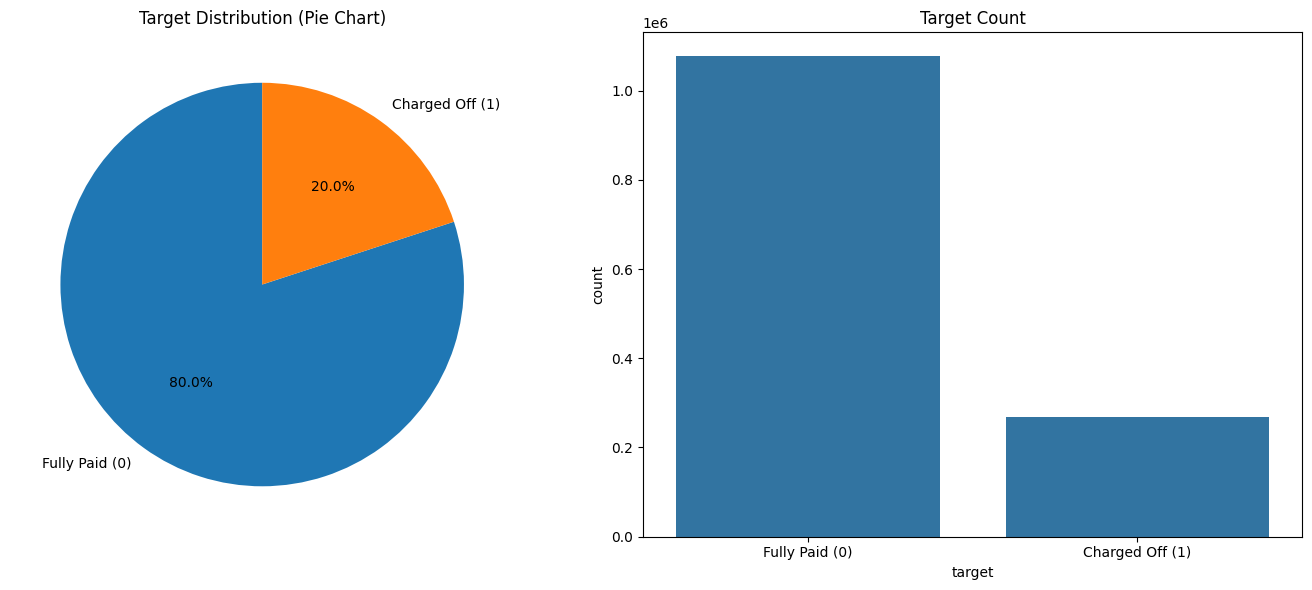

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df['target'].value_counts().plot.pie(
    autopct='%1.1f%%',
    ax=axes[0],
    labels=['Fully Paid (0)', 'Charged Off (1)'],
    startangle=90
)
axes[0].set_title('Target Distribution (Pie Chart)')
axes[0].set_ylabel('')

sns.countplot(x='target', data=df, ax=axes[1])
axes[1].set_title('Target Count')
axes[1].set_xticklabels(['Fully Paid (0)', 'Charged Off (1)'])

plt.tight_layout()
plt.show()

## Missing Values

Visualizing missing data patterns.

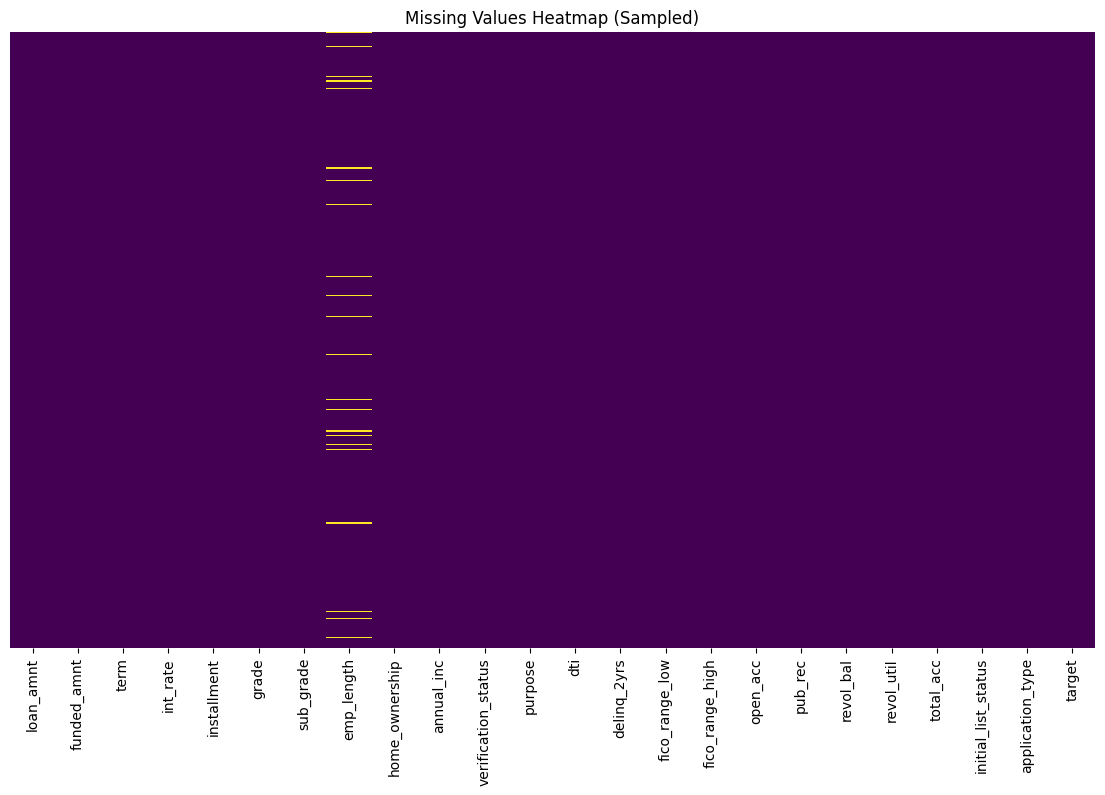

emp_length    5.835904
revol_util    0.063703
dti           0.027800
dtype: float64


In [5]:
plt.figure(figsize=(14, 8))
sample_df = df.sample(n=min(100000, len(df)), random_state=42)
sns.heatmap(sample_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Sampled)')
plt.show()

missing_pct = df.isnull().mean() * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

## Univariate Analysis

Distribution of numerical and categorical features.

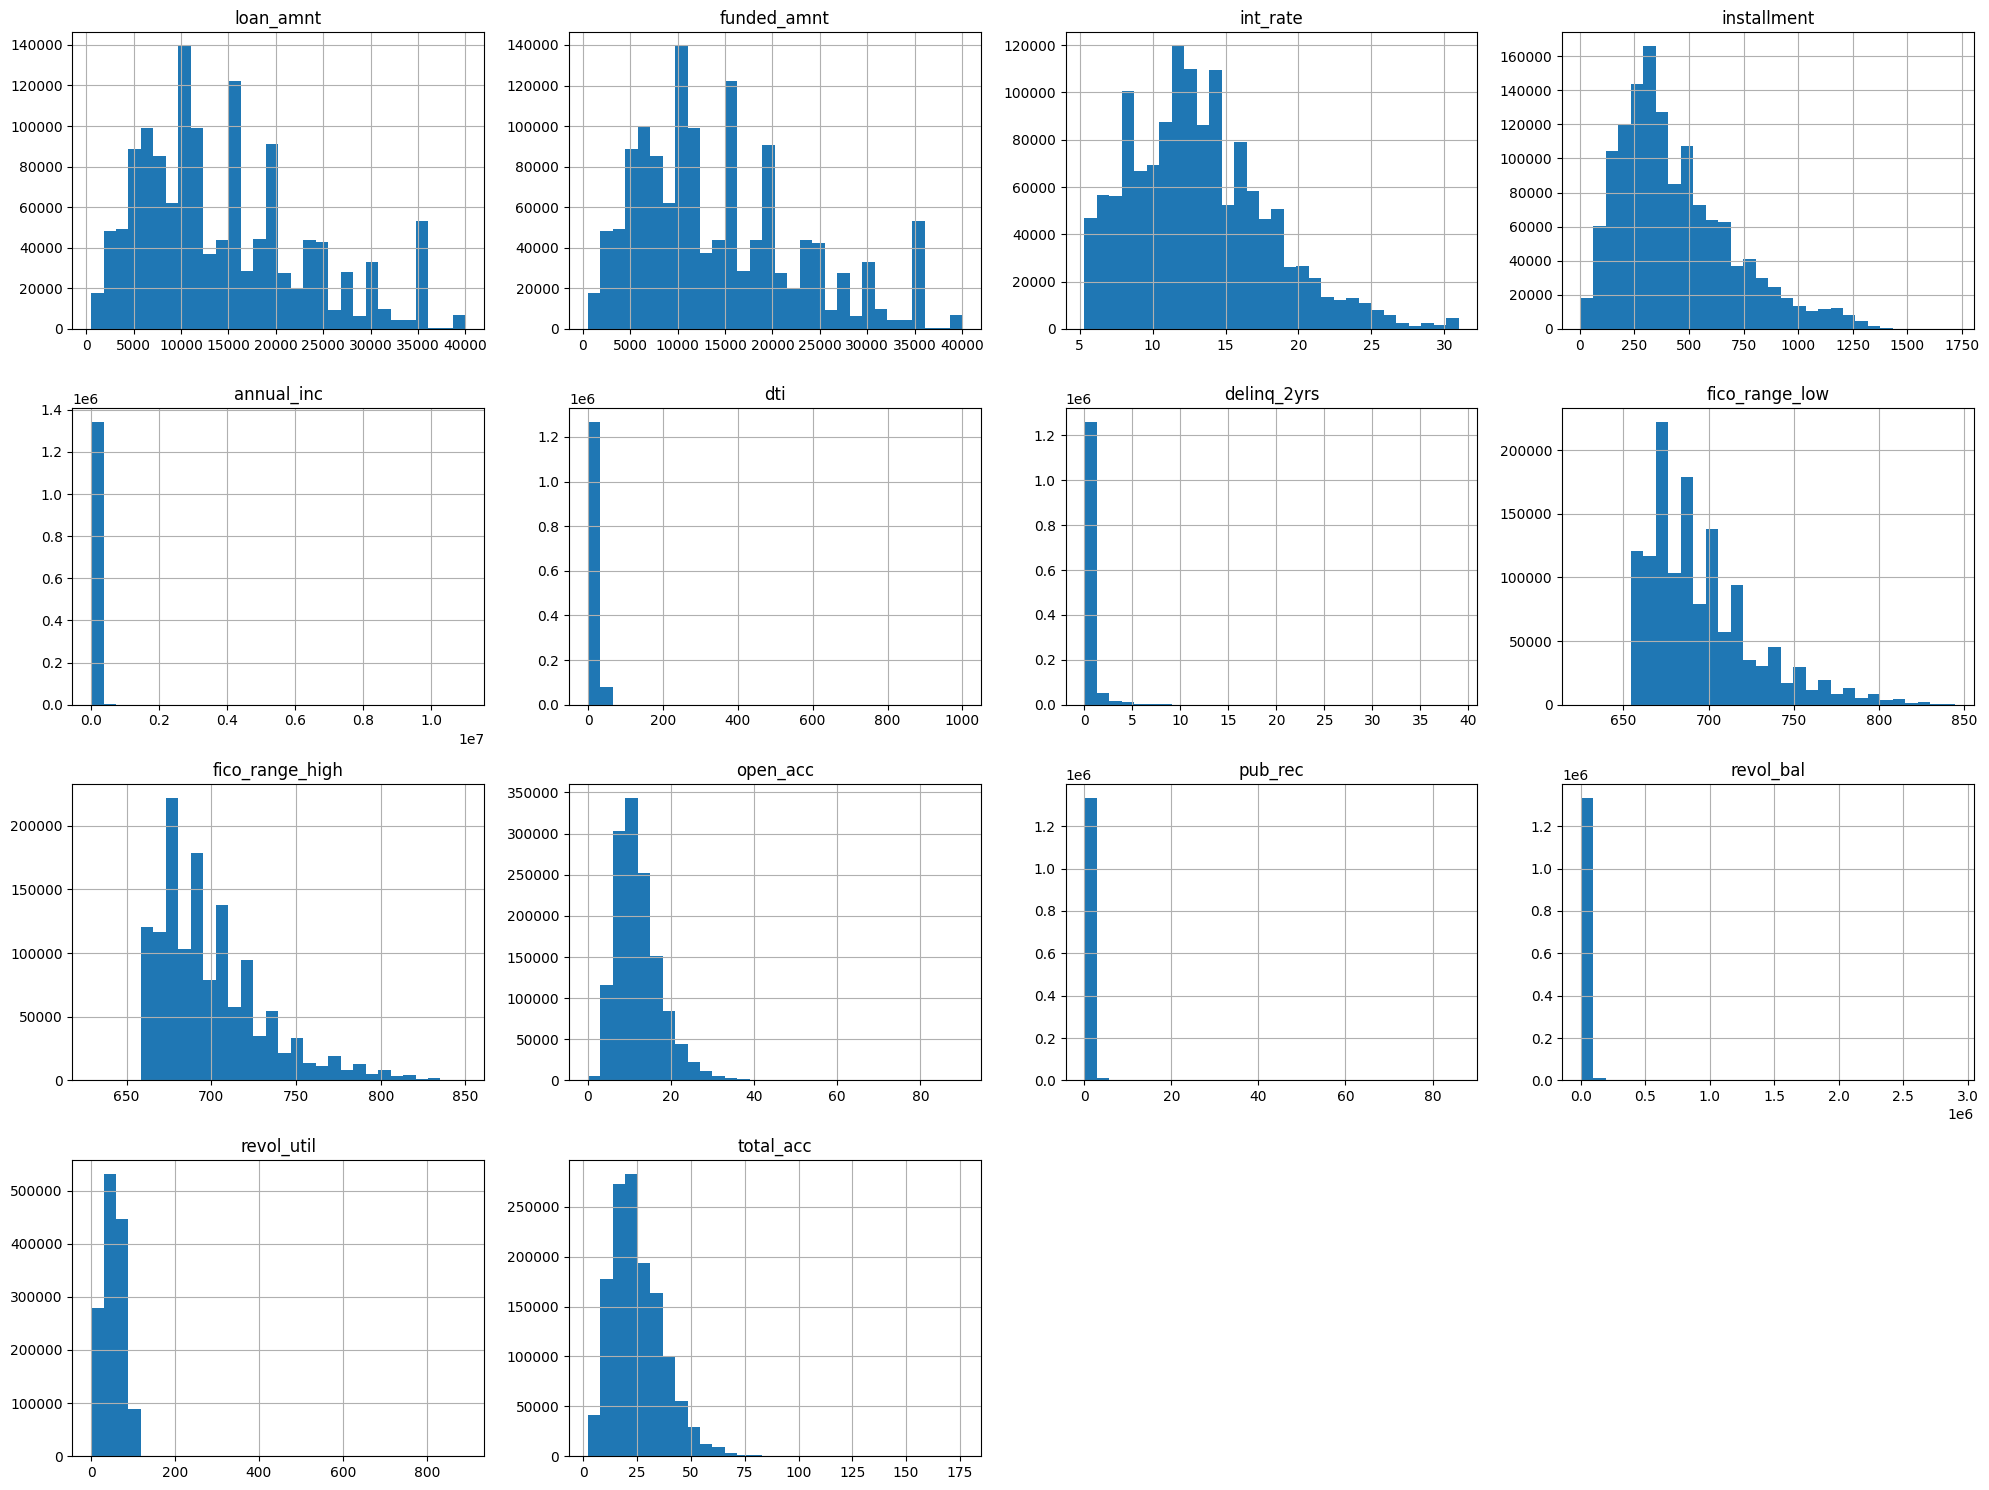

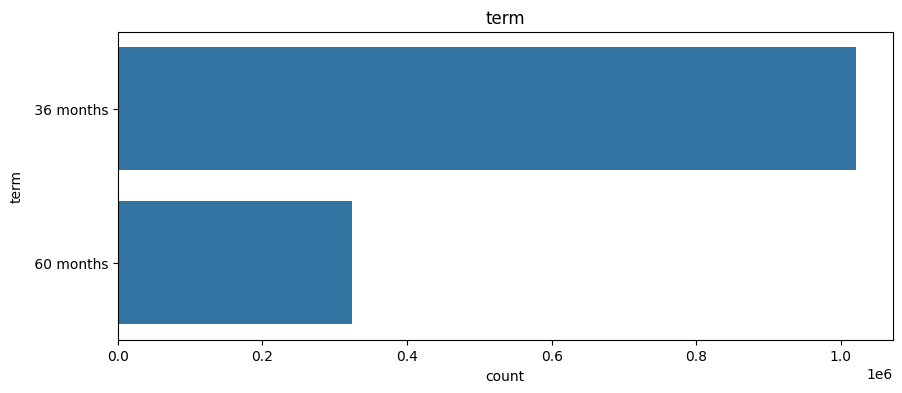

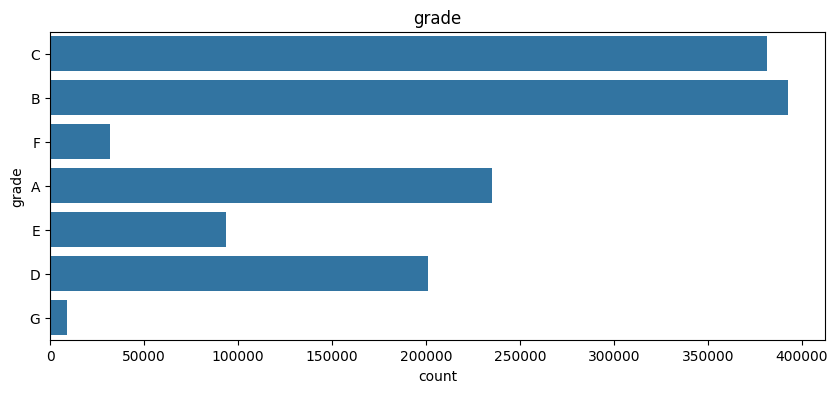

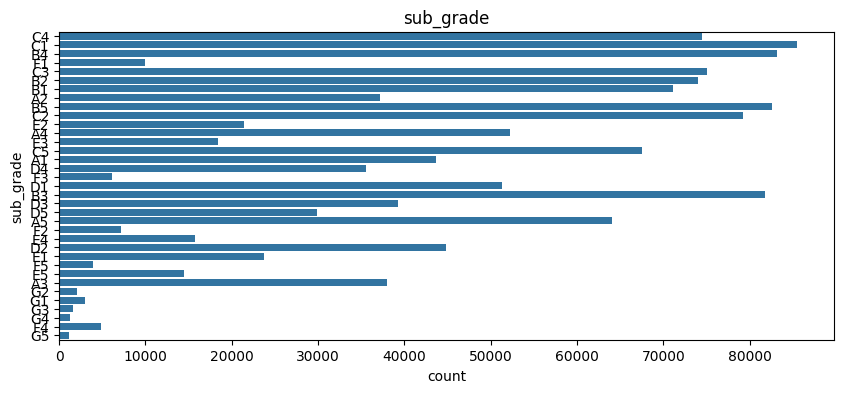

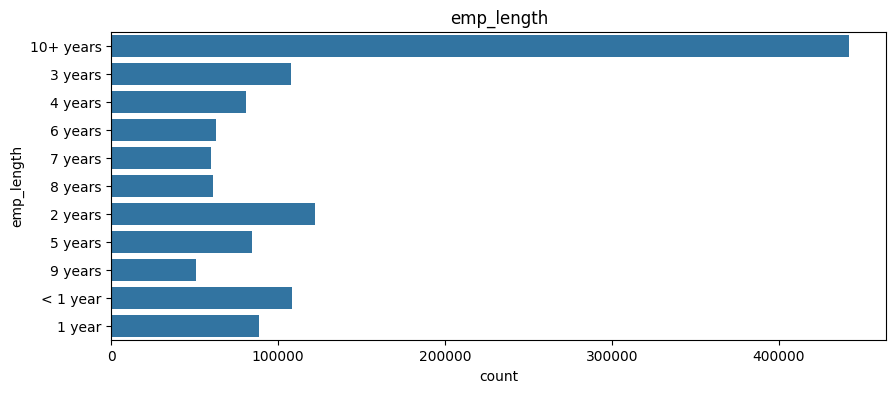

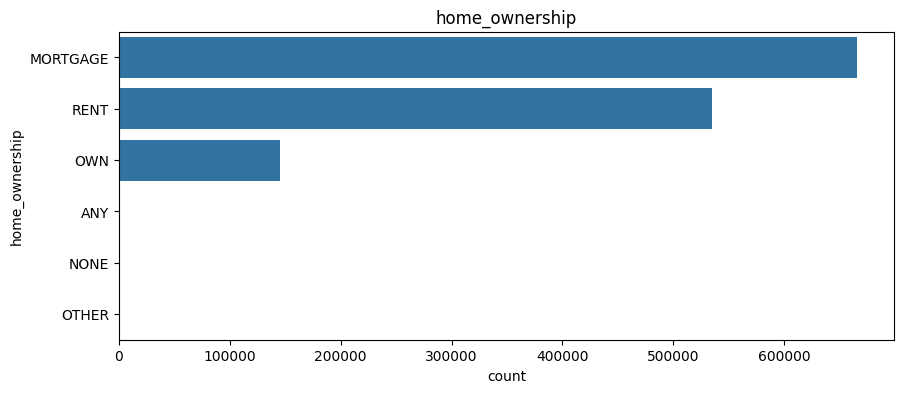

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('target')
cat_cols = df.select_dtypes(exclude=[np.number]).columns

df[num_cols].hist(bins=30, figsize=(20, 15))
plt.tight_layout()
plt.show()

for col in cat_cols[:5]:
    plt.figure(figsize=(10, 4))
    sns.countplot(y=col, data=df)
    plt.title(col)
    plt.show()

## Correlation

Correlation analysis between numerical variables.

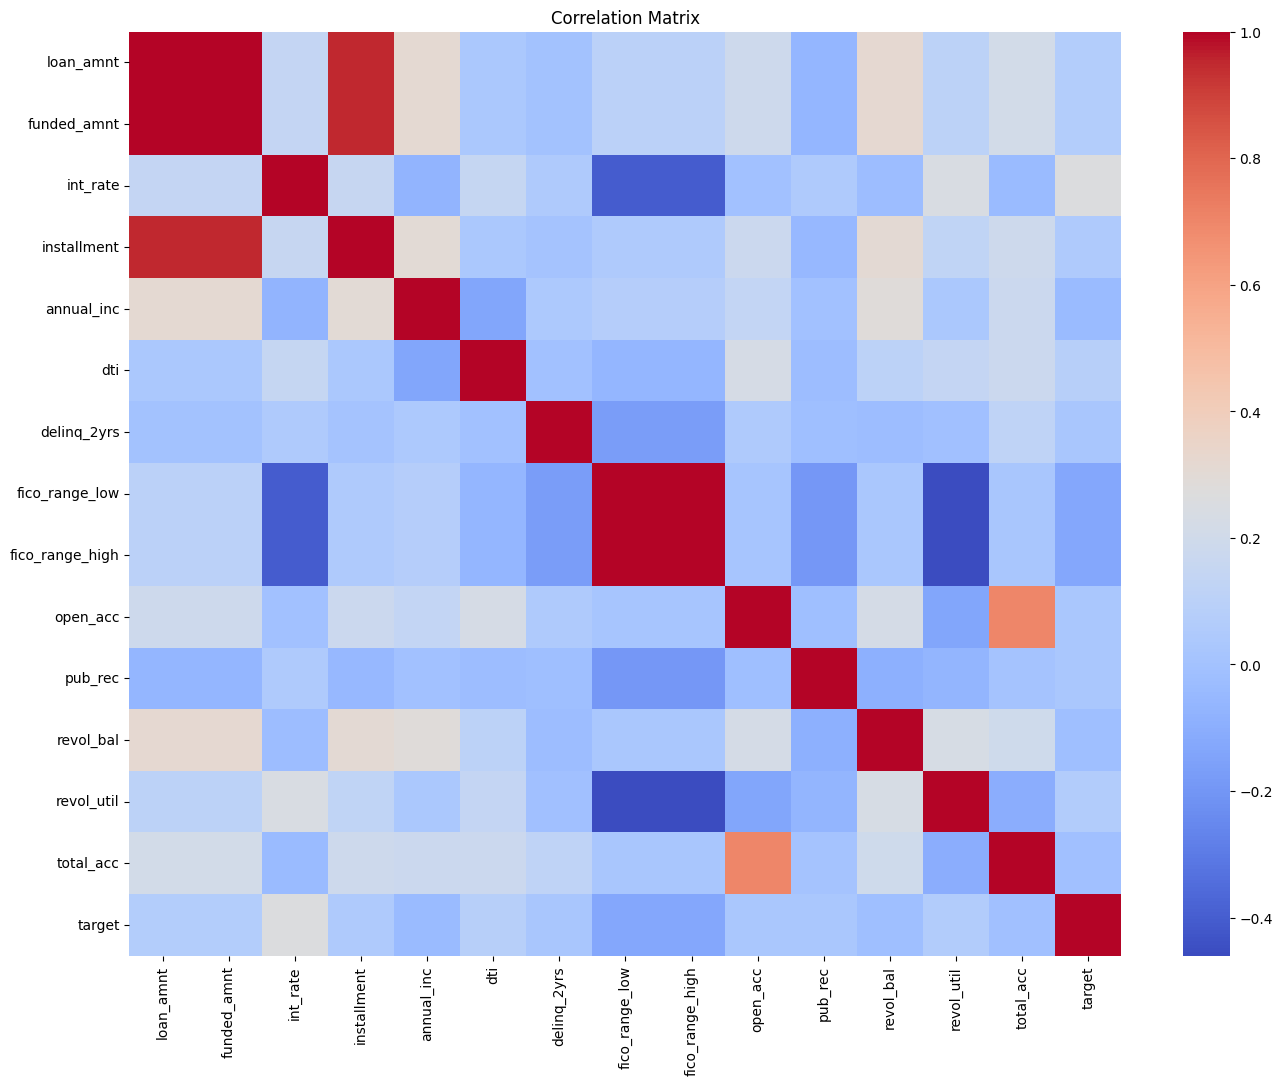

In [7]:
plt.figure(figsize=(16, 12))
corr = df[num_cols.tolist() + ['target']].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix')
plt.show()

## Findings Summary

- Shape/Dtypes: 
- Target Distribution: 
- Missing Values: 
- Distributions: 
- Correlation Insights: 